In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

**Heart Disease Risk Analysis**
 **Challenge** | Day 1
**Track:** Data Science / Analytics
**Dataset:** Heart Disease UCI
**Goal:** Load, clean, and perform exploratory data analysis (EDA)

# Step 1: Install & Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)
from xgboost import XGBClassifier


warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print( 'Libraries loaded successfully')

Libraries loaded successfully


# Step 2: Load the Dataset

In [4]:
df = pd.read_csv('/kaggle/input/datasets/uahmad12/heart-disease-uci/heart_disease_uci.csv')

print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]} | Columns: {df.shape[1]}')
df.head()

Shape: (920, 16)
Rows: 920 | Columns: 16


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


# Step 3: Data Overview

In [5]:
# Column names and data types
print('--- Data Types ---')
print(df.dtypes)
print()

# Statistical summary
print('--- Statistical Summary ---')
df.describe().T

--- Data Types ---
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

--- Statistical Summary ---


,count,mean,std,min,25%,50%,75%,max
id,920.0,460.500000,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,53.510870,9.424685,28.0,47.00,54.0,60.00,77.0
trestbps,861.0,132.132404,19.066070,0.0,120.00,130.0,140.00,200.0
chol,890.0,199.130337,110.780810,0.0,175.00,223.0,268.00,603.0
thalch,865.0,137.545665,25.926276,60.0,120.00,140.0,157.00,202.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.00,0.5,1.50,6.2
ca,309.0,0.676375,0.935653,0.0,0.00,0.0,1.00,3.0
num,920.0,0.995652,1.142693,0.0,0.00,1.0,2.00,4.0


In [6]:
# Column reference guide
column_guide = {
    'age':      'Age of the patient',
    'sex':      '1 = Male, 0 = Female',
    'dataset':  'Source location (Cleveland, Hungary, etc.)',
    'cp':       'Chest pain type (0-3)',
    'trestbps': 'Resting blood pressure (mm Hg)',
    'chol':     'Serum cholesterol (mg/dl)',
    'fbs':      'Fasting blood sugar > 120 mg/dl (1=True)',
    'restecg':  'Resting ECG results (0-2)',
    'thalch':   'Max heart rate achieved',
    'exang':    'Exercise induced angina (1=Yes)',
    'oldpeak':  'ST depression induced by exercise',
    'slope':    'Slope of peak exercise ST segment',
    'ca':       'Number of major vessels (0-3)',
    'thal':     'Thalassemia type',
    'num':      'Target: 0 = No disease, 1-4 = Disease present'
}

print('--- Column Guide ---')
for col, desc in column_guide.items():
    print(f'  {col:<12} → {desc}')

--- Column Guide ---
  age          → Age of the patient
  sex          → 1 = Male, 0 = Female
  dataset      → Source location (Cleveland, Hungary, etc.)
  cp           → Chest pain type (0-3)
  trestbps     → Resting blood pressure (mm Hg)
  chol         → Serum cholesterol (mg/dl)
  fbs          → Fasting blood sugar > 120 mg/dl (1=True)
  restecg      → Resting ECG results (0-2)
  thalch       → Max heart rate achieved
  exang        → Exercise induced angina (1=Yes)
  oldpeak      → ST depression induced by exercise
  slope        → Slope of peak exercise ST segment
  ca           → Number of major vessels (0-3)
  thal         → Thalassemia type
  num          → Target: 0 = No disease, 1-4 = Disease present


# Step 4: Data Cleaning

In [7]:
# --- Check for missing values ---
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print(' No missing values found!')
else:
    print('⚠️  Missing values detected:')
    print(missing_df)

⚠️  Missing values detected:
          Missing Count  Missing %
trestbps             59       6.41
chol                 30       3.26
fbs                  90       9.78
restecg               2       0.22
thalch               55       5.98
exang                55       5.98
oldpeak              62       6.74
slope               309      33.59
ca                  611      66.41
thal                486      52.83


In [8]:
# Numeric columns: fill with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Categorical columns: fill with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    mode_val = df[col].mode()
    if not mode_val.empty:
        df[col] = df[col].fillna(mode_val.iloc[0])

print(f' Missing values handled. Remaining nulls: {df.isnull().sum().sum()}')

 Missing values handled. Remaining nulls: 0


In [9]:
# --- Check and remove duplicates ---
dupes = df.duplicated().sum()
print(f'Duplicate rows found: {dupes}')
df.drop_duplicates(inplace=True)
print(f'Dataset shape after cleaning: {df.shape}')

Duplicate rows found: 0
Dataset shape after cleaning: (920, 16)


In [10]:
# --- Create binary target column ---
# 0 = No Disease | 1 = Disease Present
df['target'] = (df['num'] > 0).astype(int)

print('Target distribution:')
print(df['target'].value_counts())
print(f"\nDisease prevalence: {df['target'].mean()*100:.1f}%")

Target distribution:
target
1    509
0    411
Name: count, dtype: int64

Disease prevalence: 55.3%


# Step 5: Exploratory Data Analysis (EDA)

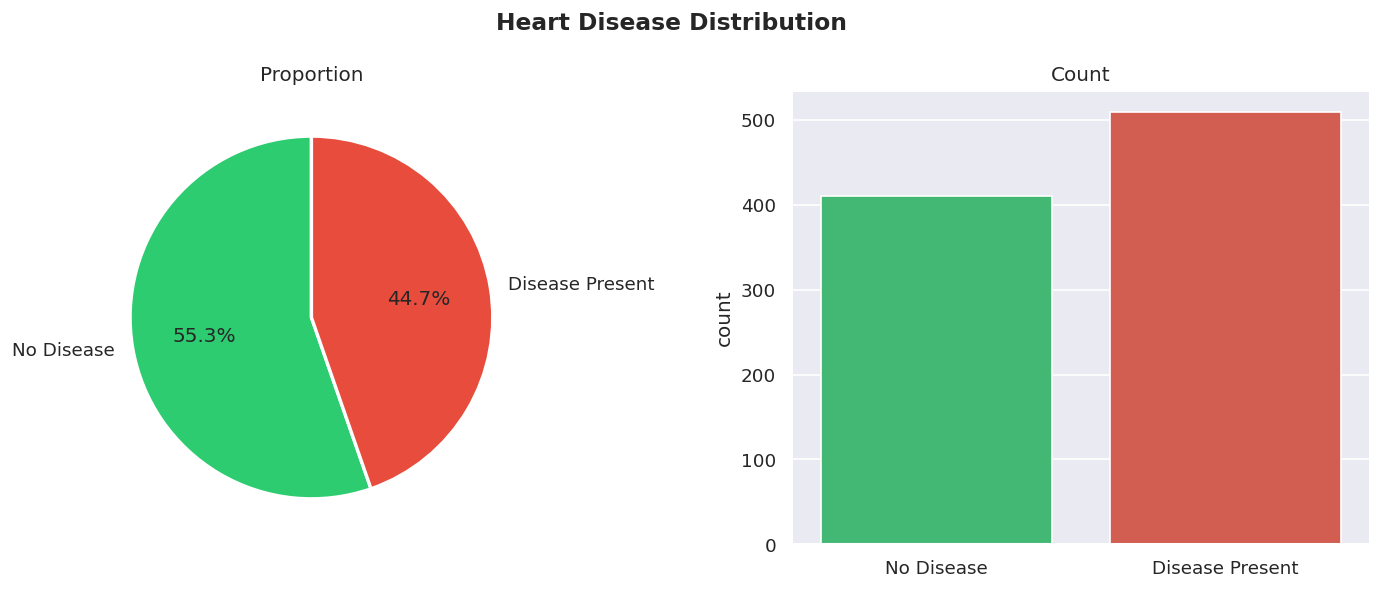

In [11]:
# --- 1. Target Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Heart Disease Distribution', fontsize=14, fontweight='bold')

labels = ['No Disease', 'Disease Present']
counts = df['target'].value_counts()

axes[0].pie(counts, labels=labels, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Proportion')

sns.countplot(data=df, x='target', palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_xticklabels(labels)
axes[1].set_title('Count')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('01_target_distribution.png', bbox_inches='tight')
plt.show()

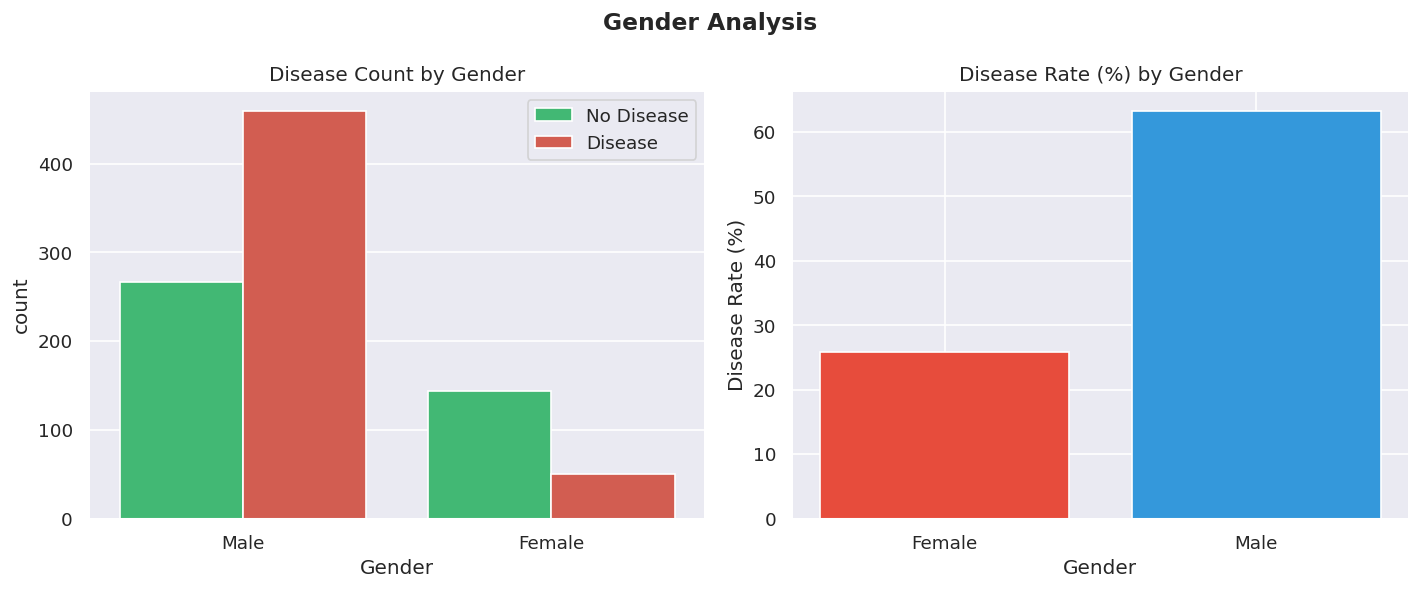

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Gender Analysis', fontsize=14, fontweight='bold')

sns.countplot(data=df, x='sex', hue='target',
              palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Disease Count by Gender')
axes[0].legend(['No Disease', 'Disease'])
axes[0].set_xlabel('Gender')

disease_rate = df.groupby('sex')['target'].mean() * 100
axes[1].bar(disease_rate.index, disease_rate.values,
            color=['#e74c3c', '#3498db'], edgecolor='white')
axes[1].set_title('Disease Rate (%) by Gender')
axes[1].set_ylabel('Disease Rate (%)')
axes[1].set_xlabel('Gender')

plt.tight_layout()
plt.savefig('03_gender_analysis.png', bbox_inches='tight')
plt.show()

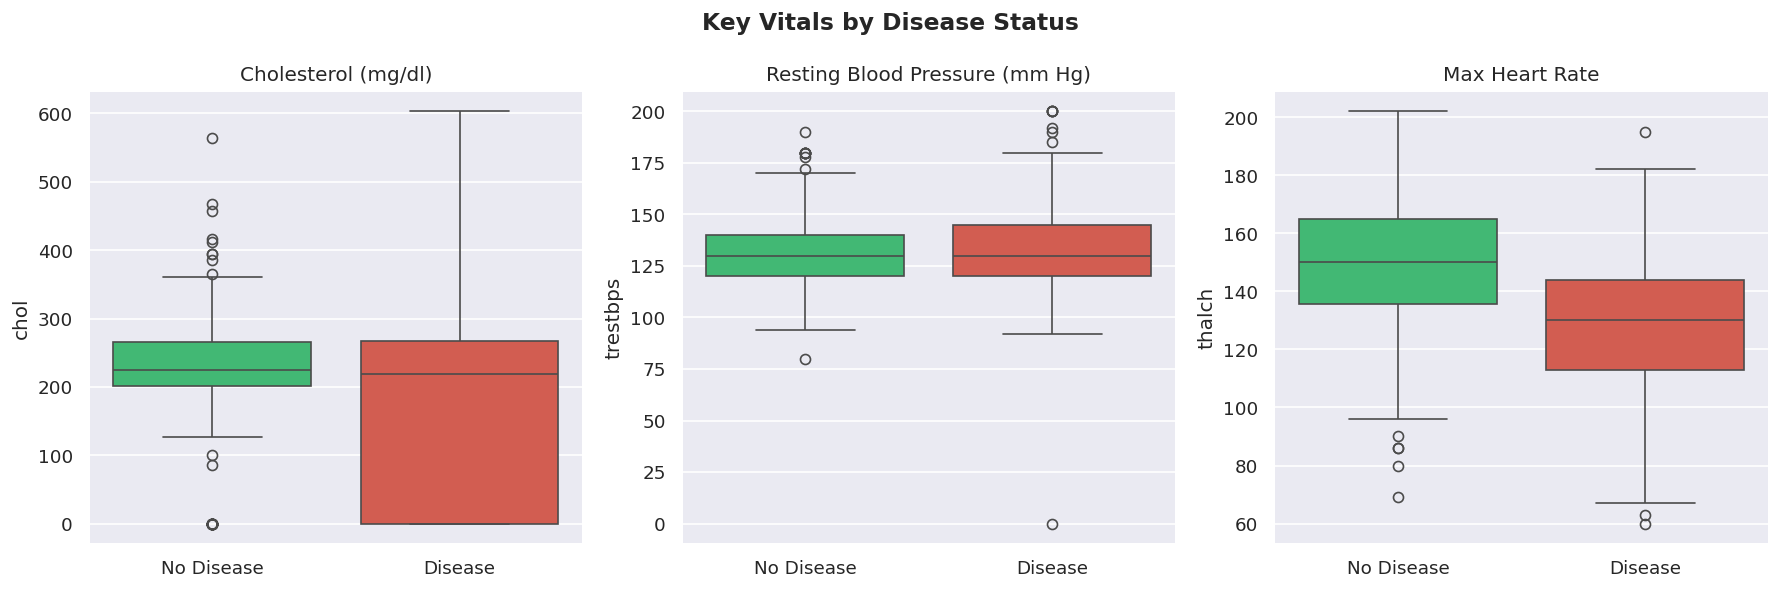

In [13]:
vitals = ['chol', 'trestbps', 'thalch']
vital_labels = ['Cholesterol (mg/dl)', 'Resting Blood Pressure (mm Hg)', 'Max Heart Rate']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Key Vitals by Disease Status', fontsize=14, fontweight='bold')

for i, (col, label) in enumerate(zip(vitals, vital_labels)):
    sns.boxplot(data=df, x='target', y=col,
                palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_title(label)
    axes[i].set_xticklabels(['No Disease', 'Disease'])
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('04_vitals_boxplot.png', bbox_inches='tight')
plt.show()

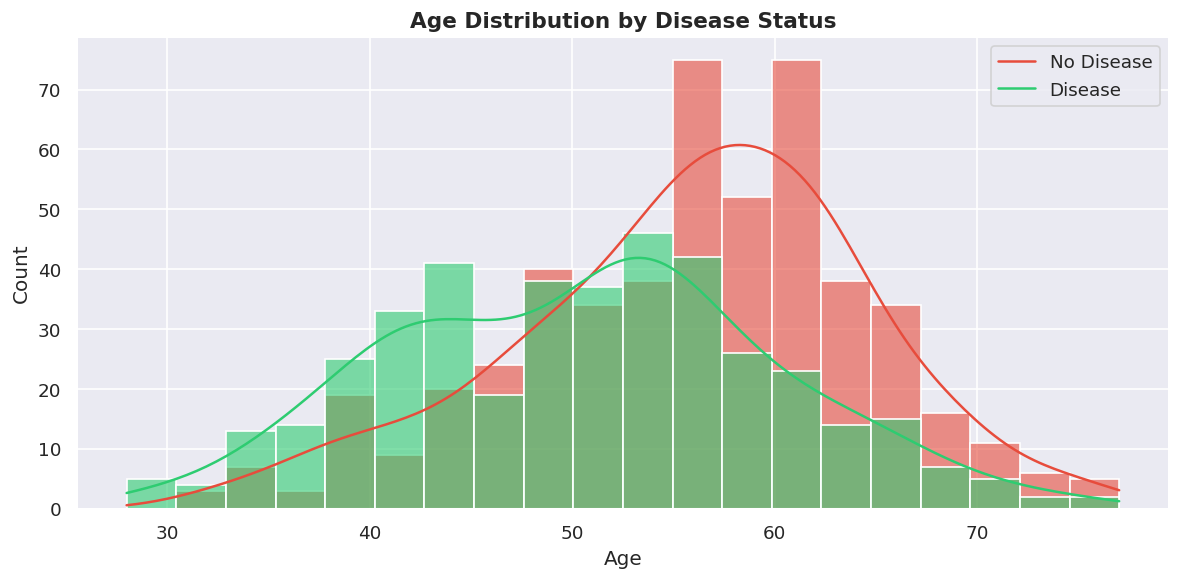

In [14]:
# --- 2. Age Distribution by Disease Status ---
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='target', bins=20, kde=True,
             palette=['#2ecc71', '#e74c3c'], alpha=0.6)
plt.title('Age Distribution by Disease Status', fontsize=13, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(labels=['No Disease', 'Disease'])
plt.tight_layout()
plt.savefig('02_age_distribution.png', bbox_inches='tight')
plt.show()

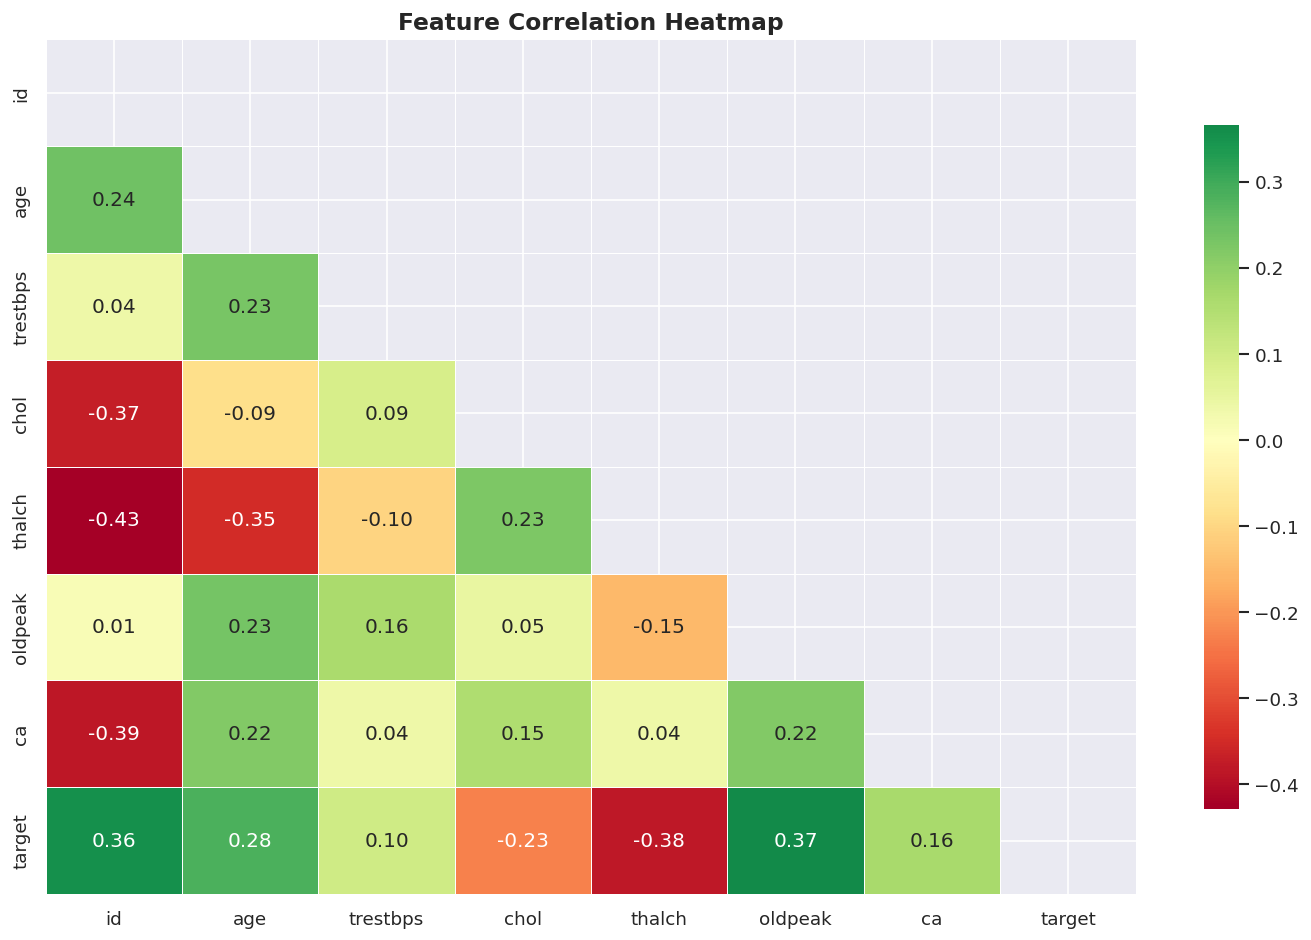

In [15]:
# --- 5. Correlation Heatmap ---
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['num'], errors='ignore')
corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_correlation_heatmap.png', bbox_inches='tight')
plt.show()

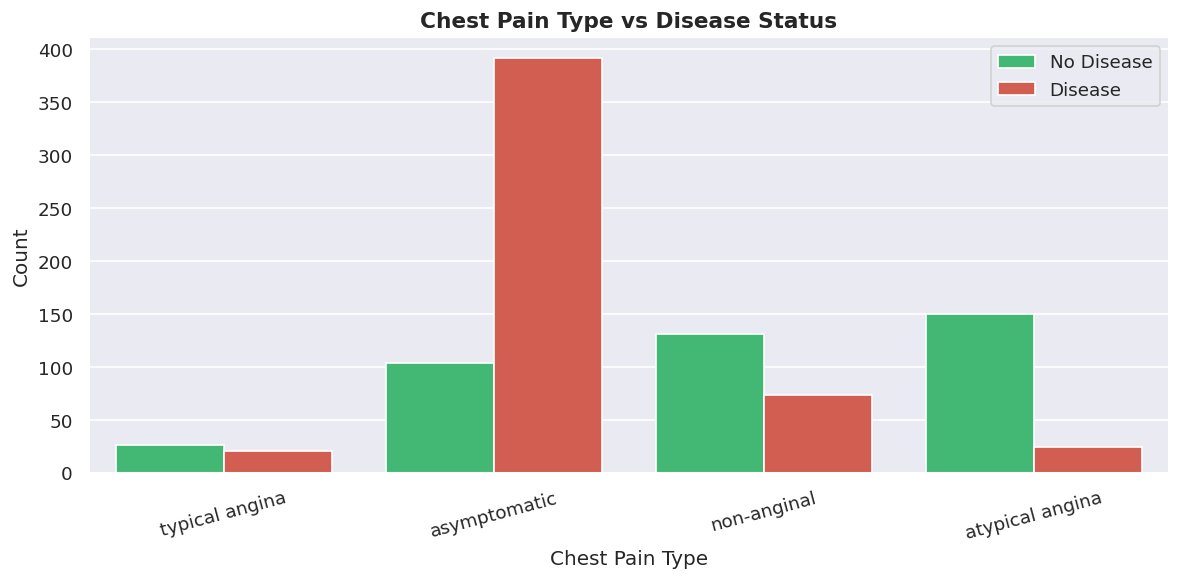

In [16]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='cp', hue='target',
              palette=['#2ecc71', '#e74c3c'])
plt.title('Chest Pain Type vs Disease Status', fontsize=13, fontweight='bold')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.legend(labels=['No Disease', 'Disease'])
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('06_chest_pain.png', bbox_inches='tight')
plt.show()

In [17]:
df_model = df.drop(columns=['id', 'num'], errors='ignore')

le = LabelEncoder()
cat_cols = df_model.select_dtypes(include=['object']).columns

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print(' Encoding done')
print(f'Features: {df_model.shape[1] - 1}')

 Encoding done
Features: 14


In [18]:
X = df_model.drop(columns=['target'])
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

Train: 736 samples
Test:  184 samples


In [19]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print(f' Model trained!')
print(f'Accuracy:      {acc*100:.2f}%')
print(f'ROC-AUC:       {auc:.4f}')
print(f'Cross-val:     {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')

 Model trained!
Accuracy:      85.87%
ROC-AUC:       0.9183
Cross-val:     71.74% ± 9.61%


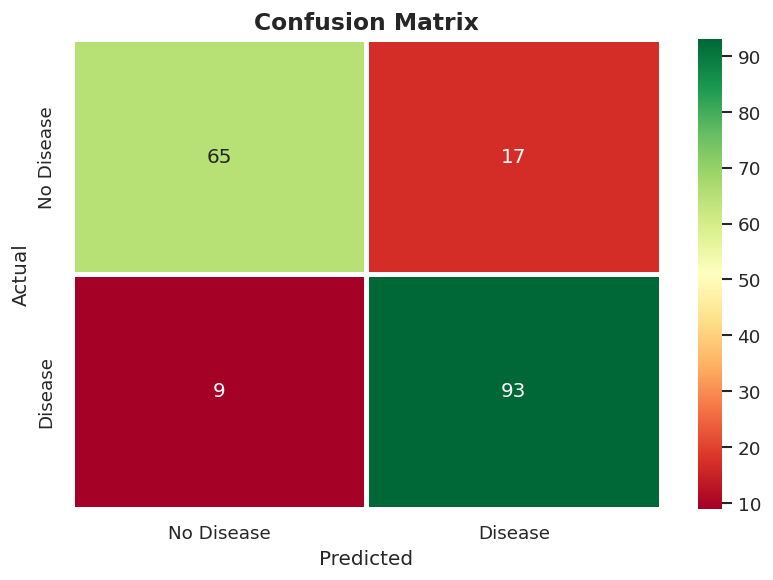

              precision    recall  f1-score   support

  No Disease       0.88      0.79      0.83        82
     Disease       0.85      0.91      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.85      0.86       184
weighted avg       0.86      0.86      0.86       184



In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'],
            linewidths=2, linecolor='white')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('07_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

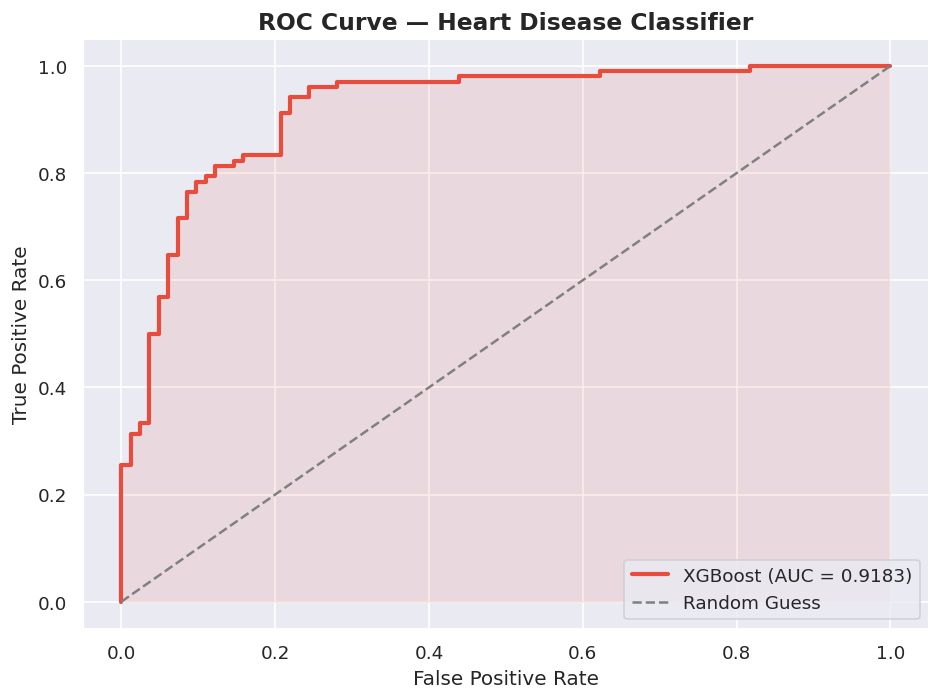

In [21]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2.5, label=f'XGBoost (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Guess')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Heart Disease Classifier', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('08_roc_curve.png', bbox_inches='tight')
plt.show()

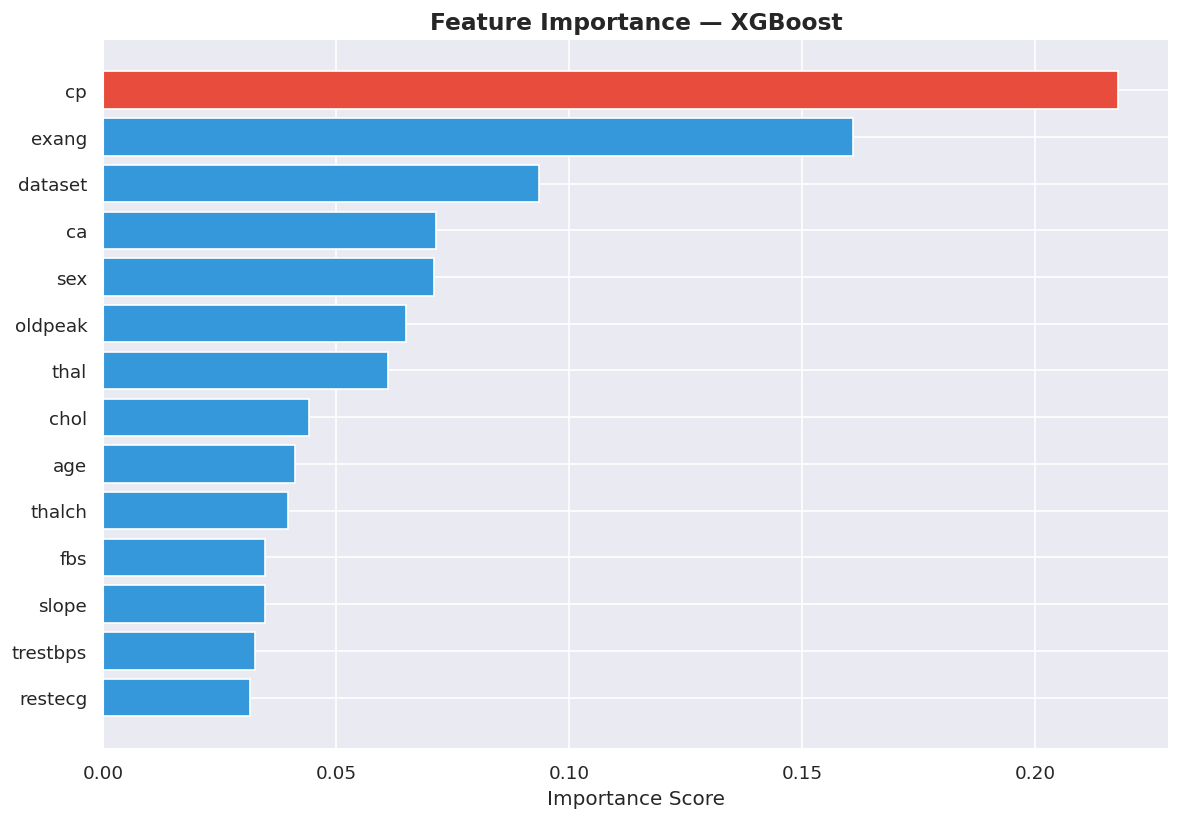

 Most important feature: cp


In [22]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if x == importance_df['Importance'].max()
          else '#3498db' for x in importance_df['Importance']]
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color=colors, edgecolor='white')
plt.title('Feature Importance — XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('09_feature_importance.png', bbox_inches='tight')
plt.show()

top = importance_df.iloc[-1]['Feature']
print(f' Most important feature: {top}')